In [1]:
import torch
import copy
import numpy as np
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.model_selection import train_test_split

from torch import nn, optim

import torch.nn.functional as F

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set(style= 'whitegrid', palette= 'muted', font_scale= 1.2)
HAPPY_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]
sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))

rcParams['figure.figsize'] = 12, 8

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

In [2]:
!gdown --id 16MIleqoIr1vYxlGk4GKnGmrsCPuWkkpT


usage: gdown [-h] [-V] [-O OUTPUT] [-q] [--proxy PROXY] [--speed SPEED]
             [--no-cookies] [--no-check-certificate] [--continue] [--folder]
             [--json] [--format FORMAT] [--user-agent USER_AGENT]
             url_or_id
gdown: error: unrecognized arguments: --id


In [3]:
from scipy.io import arff
import pandas as pd

# Correct Mac paths
train_path = "/Users/arshiyasoni/Desktop/NLP-Project/ECG-Anomaly-Detection/SEM 7 project/ECG5000/ECG5000_TRAIN.arff"

test_path = "/Users/arshiyasoni/Desktop/NLP-Project/ECG-Anomaly-Detection/SEM 7 project/ECG5000/ECG5000_TEST.arff"


# Load training data
data_train, meta_train = arff.loadarff(train_path)
df_train = pd.DataFrame(data_train)

# Load testing data
data_test, meta_test = arff.loadarff(test_path)
df_test = pd.DataFrame(data_test)


print("Training data shape:", df_train.shape)
print("Testing data shape:", df_test.shape)


Training data shape: (500, 141)
Testing data shape: (4500, 141)


In [4]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
df_train.head()


,att1,att2,att3,att4,att5,att6,att7,att8,att9,att10,...,att132,att133,att134,att135,att136,att137,att138,att139,att140,target
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,b'1'
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,b'1'
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,b'1'
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,b'1'
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,b'1'


In [6]:
df_test.head()

,att1,att2,att3,att4,att5,att6,att7,att8,att9,att10,...,att132,att133,att134,att135,att136,att137,att138,att139,att140,target
0,3.690844,0.711414,-2.114091,-4.141007,-4.574472,-3.431909,-1.950791,-1.107067,-0.632322,0.334577,...,0.022847,0.188937,0.480932,0.629250,0.577291,0.665527,1.035997,1.492287,-1.905073,b'1'
1,-1.348132,-3.996038,-4.226750,-4.251187,-3.477953,-2.228422,-1.808488,-1.534242,-0.779861,-0.397999,...,1.570938,1.591394,1.549193,1.193077,0.515134,0.126274,0.267532,1.071148,-1.164009,b'1'
2,1.024295,-0.590314,-1.916949,-2.806989,-3.527905,-3.638675,-2.779767,-2.019031,-1.980754,-1.440680,...,0.443502,0.827582,1.237007,1.235121,1.738103,1.800767,1.816301,1.473963,1.389767,b'1'
3,0.545657,-1.014383,-2.316698,-3.634040,-4.196857,-3.758093,-3.194444,-2.221764,-1.588554,-1.202146,...,0.777530,1.119240,0.902984,0.554098,0.497053,0.418116,0.703108,1.064602,-0.044853,b'1'
4,0.661133,-1.552471,-3.124641,-4.313351,-4.017042,-3.005993,-1.832411,-1.503886,-1.071705,-0.521316,...,1.280823,1.494315,1.618764,1.447449,1.238577,1.749692,1.986803,1.422756,-0.357784,b'1'


In [7]:

df = pd.concat([df_train, df_test], ignore_index=True)


df = df.sample(frac=1.0, random_state=42).reset_index(drop=True)


print(df.shape)


(5000, 141)


In [8]:
CLASS_NORMAL = 1

class_names = ['Normal', 'R on T', 'PVC', 'SP', 'UB']

In [9]:
new_columns = list(df.columns)
new_columns[-1] = 'target'    
df.columns =new_columns
df.columns

Index(['att1', 'att2', 'att3', 'att4', 'att5', 'att6', 'att7', 'att8', 'att9',
       'att10',
       ...
       'att132', 'att133', 'att134', 'att135', 'att136', 'att137', 'att138',
       'att139', 'att140', 'target'],
      dtype='object', length=141)

In [10]:

df.target.value_counts()

target
b'1'    2919
b'2'    1767
b'4'     194
b'3'      96
b'5'      24
Name: count, dtype: int64

/var/folders/tc/s_gvvcyn16nc25cl5cvpsftr0000gn/T/ipykernel_69748/3273524691.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names)


[Text(0.0, 0, 'Normal'),
 Text(500.0, 0, 'R on T'),
 Text(1000.0, 0, 'PVC'),
 Text(1500.0, 0, 'SP'),
 Text(2000.0, 0, 'UB'),
 Text(2500.0, 0, ''),
 Text(3000.0, 0, ''),
 Text(3500.0, 0, '')]

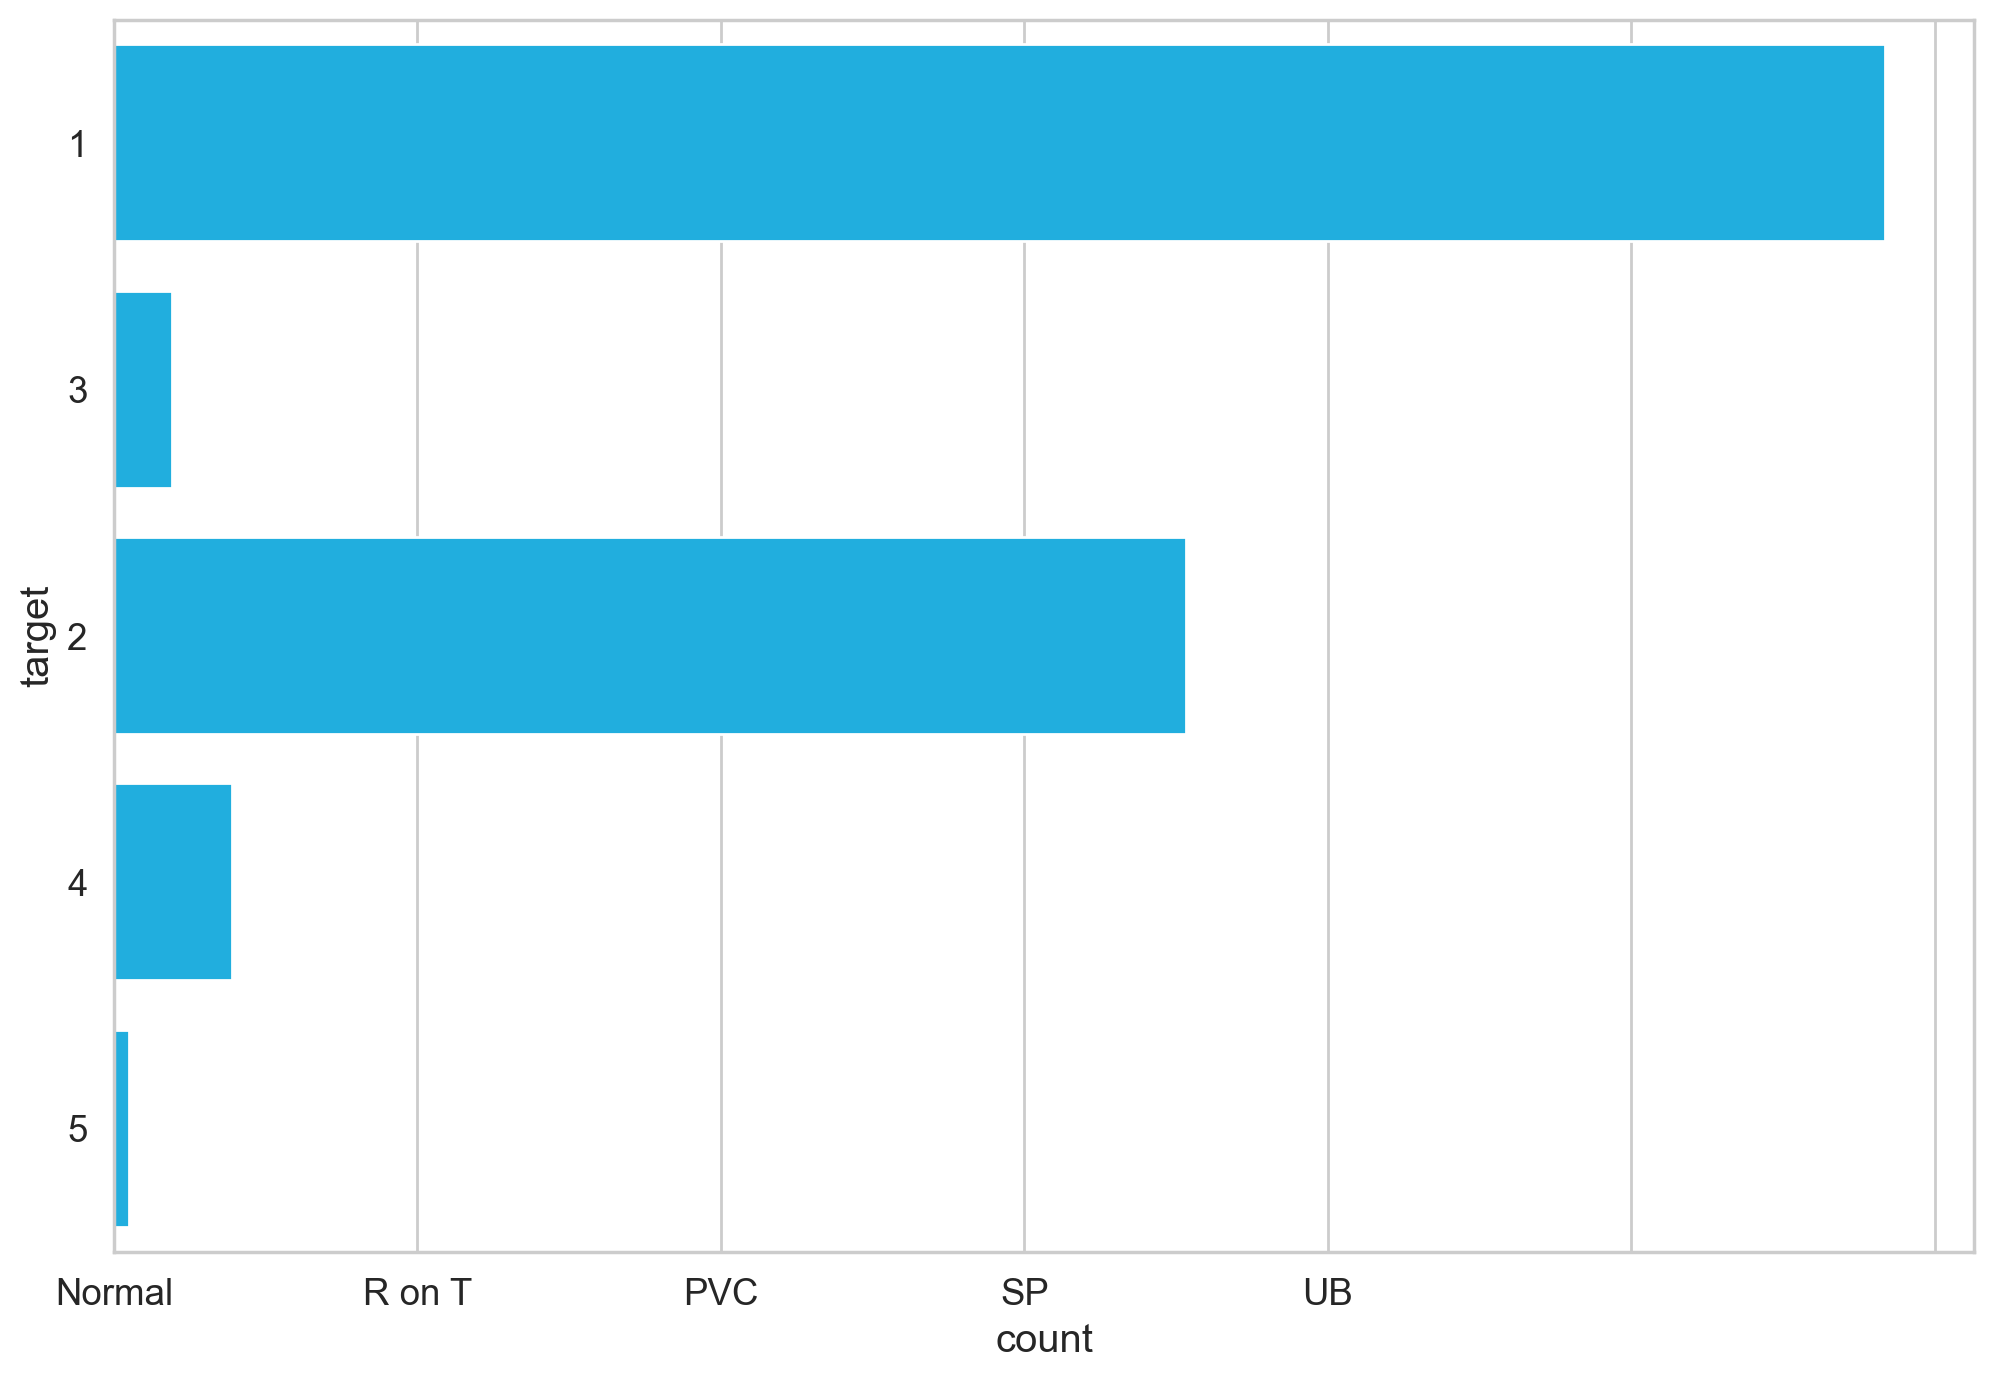

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt 
ax = sns.countplot(df.target)
ax.set_xticklabels(class_names)


In [12]:
def plot_time_series_class(data, class_name, ax, n_steps=10):
  time_series_df = pd.DataFrame(data)

  smooth_path = time_series_df.rolling(n_steps).mean()
  path_deviation = 2 * time_series_df.rolling(n_steps).std()

  under_line = (smooth_path - path_deviation)[0]
  over_line = (smooth_path + path_deviation)[0]

  ax.plot(smooth_path, linewidth=2)
  ax.fill_between(
    path_deviation.index,
    under_line,
    over_line,
    alpha=.125
  )                                            
  ax.set_title(class_name)

In [13]:

'''df[df.target == str(CLASS_NORMAL)] \
    .drop(labels = 'target', axis = 1) \
    .mean(axis = 0).shape'''

"df[df.target == str(CLASS_NORMAL)]     .drop(labels = 'target', axis = 1)     .mean(axis = 0).shape"

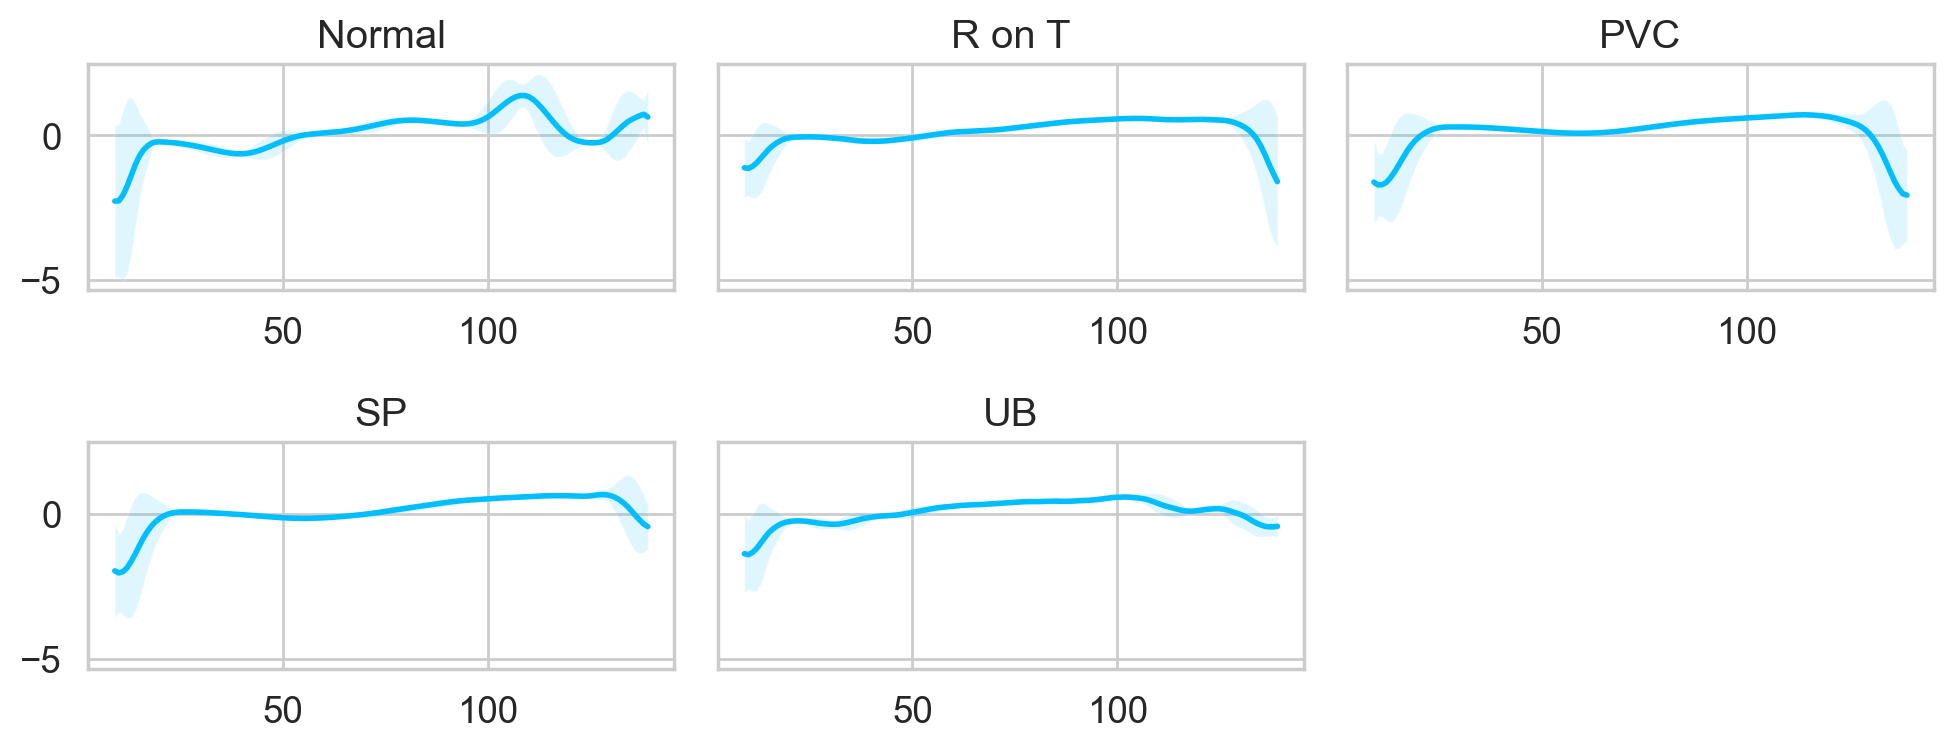

In [14]:
classes = df.target.unique()

fig, axs = plt.subplots(
  nrows=len(classes) // 3 + 1,
  ncols=3,
  sharey=True,
  figsize=(10, 4)
)

for i, cls in enumerate(classes):
  ax = axs.flat[i]
  data = df[df.target == cls] \
    .drop(labels='target', axis=1) \
    .mean(axis=0) \
    .to_numpy()                         
  plot_time_series_class(data, class_names[i], ax)

fig.delaxes(axs.flat[-1])               
fig.tight_layout();

In [15]:
normal_df = df[df.target == str(CLASS_NORMAL)].drop(labels='target', axis = 1)
normal_df.shape

(0, 140)

In [16]:
anomaly_df = df[df.target != str(CLASS_NORMAL)].drop(labels='target', axis=1)
anomaly_df.shape

(5000, 140)

In [17]:

CLASS_NORMAL = "1"  
print("CLASS_NORMAL fixed as:", CLASS_NORMAL)


mask = df['target'].astype(str) == CLASS_NORMAL
normal_df = df.loc[mask].drop(columns=['target'], errors='ignore')
anomaly_df = df.loc[~mask].drop(columns=['target'], errors='ignore')

print("normal_df.shape:", normal_df.shape)
print("anomaly_df.shape:", anomaly_df.shape)


CLASS_NORMAL fixed as: 1
normal_df.shape: (2919, 140)
anomaly_df.shape: (2081, 140)


In [18]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42  


train_df, val_df = train_test_split(normal_df, test_size=0.15, random_state=RANDOM_SEED)


val_df, test_df = train_test_split(val_df, test_size=0.5, random_state=RANDOM_SEED)


In [19]:
test_df.shape

(219, 140)

In [20]:
import numpy as np

train_sequences = train_df.astype(np.float32).to_numpy().tolist()
val_sequences = val_df.astype(np.float32).to_numpy().tolist()
test_sequences = test_df.astype(np.float32).to_numpy().tolist()
anomaly_sequences = anomaly_df.astype(np.float32).to_numpy().tolist()


In [21]:

def create_dataset(sequences):
  
  dataset = [torch.tensor(s).unsqueeze(1) for s in sequences] 

  n_seq, seq_len, n_features = torch.stack(dataset).shape

  return dataset, seq_len, n_features

In [22]:

train_dataset, seq_len, n_features = create_dataset(train_sequences)
val_dataset, _, _   = create_dataset(val_sequences)
test_dataset, _, _  = create_dataset(test_sequences)
test_anomaly_dataset, _, _ = create_dataset(anomaly_sequences)

In [23]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [24]:
test_normal_dataset, seq_len, n_features = create_dataset(test_sequences)

In [25]:
class Encoder(nn.Module):

  def __init__(self, seq_len, n_features, embedding_dim=64):
    super(Encoder, self).__init__()

    self.seq_len, self.n_features = seq_len, n_features
    self.embedding_dim, self.hidden_dim = embedding_dim, 2 * embedding_dim

    self.rnn1 = nn.LSTM(
      input_size=n_features,
      hidden_size=self.hidden_dim,
      num_layers=1,
      batch_first=True
    )
    
    self.rnn2 = nn.LSTM(
      input_size=self.hidden_dim,
      hidden_size=embedding_dim,
      num_layers=1,
      batch_first=True
    )

  def forward(self, x):
    x = x.reshape((1, self.seq_len, self.n_features))   

    x, (hidden_n, cell_n) = self.rnn1(x)
    x, (hidden_n, cell_n) = self.rnn2(x)

    return hidden_n.reshape((self.n_features, self.embedding_dim))  

In [26]:

class Decoder(nn.Module):

  def __init__(self, seq_len, input_dim=64, n_features=1):
    super(Decoder, self).__init__()

    self.seq_len, self.input_dim = seq_len, input_dim
    self.hidden_dim, self.n_features = 2 * input_dim, n_features

    self.rnn1 = nn.LSTM(
      input_size=input_dim,
      hidden_size=input_dim,
      num_layers=1,
      batch_first=True
    )

    self.rnn2 = nn.LSTM(
      input_size=input_dim,
      hidden_size=self.hidden_dim,
      num_layers=1,
      batch_first=True
    )

    
    self.output_layer = nn.Linear(self.hidden_dim, n_features)  

  def forward(self, x):
    x = x.repeat(self.seq_len, self.n_features)
    x = x.reshape((self.n_features, self.seq_len, self.input_dim))    

    x, (hidden_n, cell_n) = self.rnn1(x)
    x, (hidden_n, cell_n) = self.rnn2(x)
    x = x.reshape((self.seq_len, self.hidden_dim))

    return self.output_layer(x)

In [27]:
class RecurrentAutoencoder(nn.Module):

  def __init__(self, seq_len, n_features, embedding_dim=64):
    super(RecurrentAutoencoder, self).__init__()

    self.encoder = Encoder(seq_len, n_features, embedding_dim).to(device)
    self.decoder = Decoder(seq_len, embedding_dim, n_features).to(device)

  def forward(self, x):
    x = self.encoder(x)
    x = self.decoder(x)

    return x

In [28]:
model = RecurrentAutoencoder(seq_len, n_features, 128)
model = model.to(device) 

In [29]:
def train_model(model, train_dataset, val_dataset, n_epochs):
  optimizer = torch.optim.Adam(model.parameters(), lr= 1e-3)
  criterion = nn.L1Loss(reduction='sum').to(device)     
  
  history = dict(train=[], val=[])                      

  for epoch in range(1, n_epochs + 1):
    model = model.train()

    train_losses = []

    for seq_true in train_dataset:    
      optimizer.zero_grad()           

      seq_true = seq_true.to(device)   
      seq_pred = model(seq_true)      

      loss = criterion(seq_pred, seq_true)  

      loss.backward()                 
      optimizer.step()

      train_losses.append(loss.item())  
    val_losses = []
    model = model.eval()
    with torch.no_grad():  
      for seq_true in val_dataset:
          seq_true = seq_true.to(device)  
          seq_pred = model(seq_true)       

          loss = criterion(seq_pred, seq_true)  

          val_losses.append(loss.item())   
    train_loss = np.mean(train_losses)   
    val_loss = np.mean(val_losses)
    history['train'].append(train_loss)
    history['val'].append(val_loss)

    print(f'Epoch {epoch}: train loss = {train_loss}, val loss = {val_loss}')

  return model.eval(), history 

In [31]:
model, history = train_model(model, train_dataset, val_dataset, n_epochs= 5)

Epoch 1: train loss = 49.30836840379339, val loss = 43.265820472752125
Epoch 2: train loss = 36.8140787822688, val loss = 37.139215843862594
Epoch 3: train loss = 31.697493856061808, val loss = 32.38298500618434
Epoch 4: train loss = 30.151658918049392, val loss = 30.00038918621464
Epoch 5: train loss = 27.99885107768442, val loss = 29.70611186876689


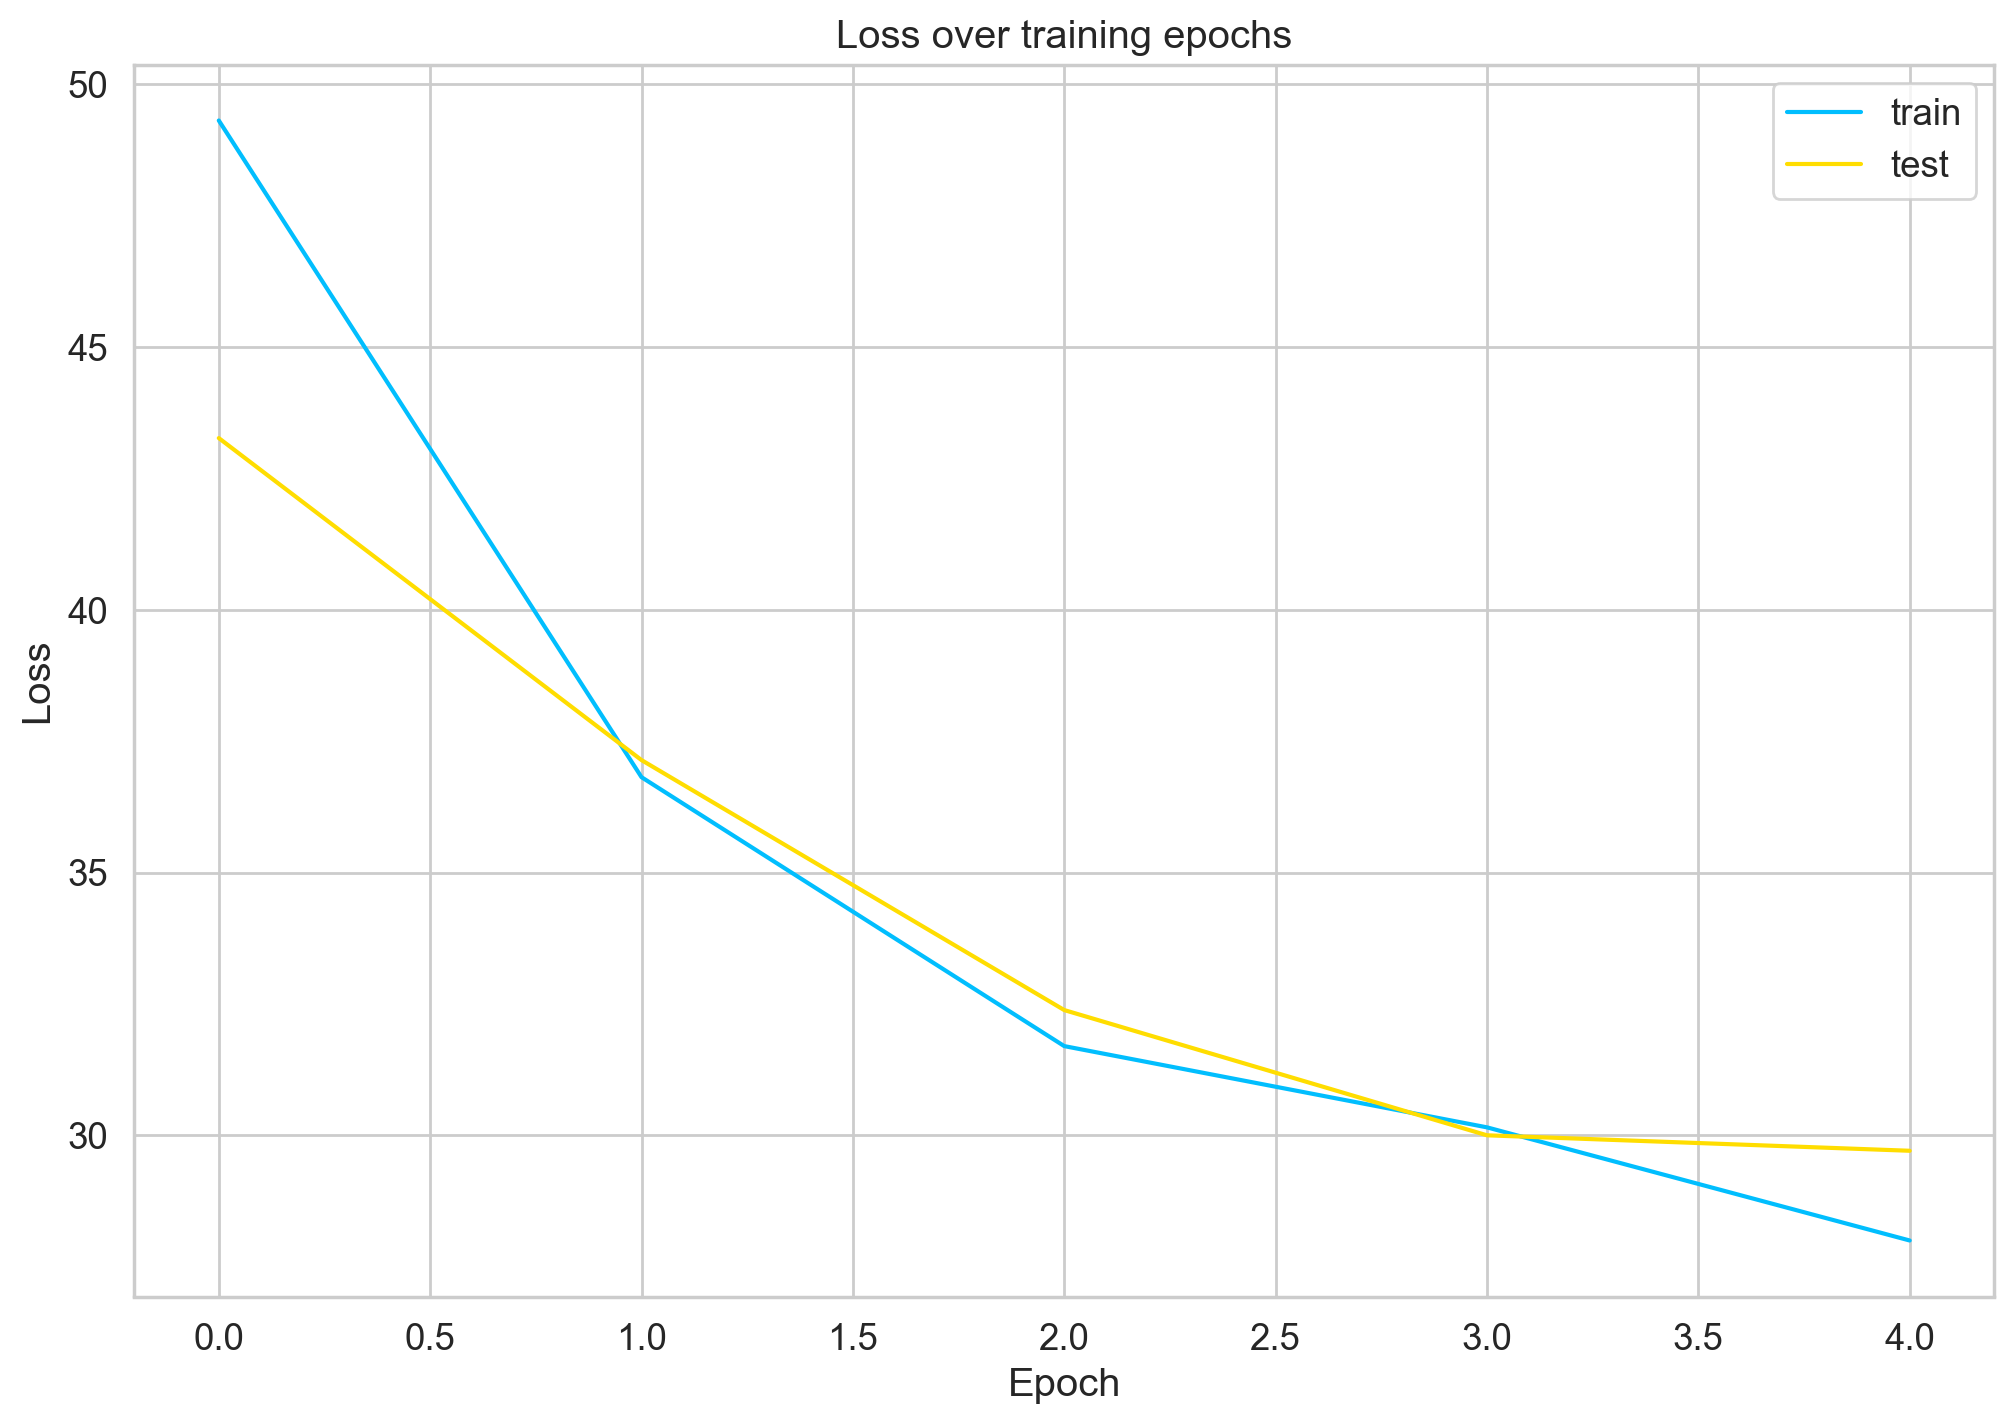

In [32]:
ax = plt.figure().gca()

ax.plot(history['train'])
ax.plot(history['val'])
plt.ylabel('Loss') 
plt.xlabel('Epoch')
plt.legend(['train', 'test'])
plt.title('Loss over training epochs')
plt.show();

In [33]:
MODEL_PATH = 'model.pth'

torch.save(model, MODEL_PATH)

In [34]:
def predict(model, dataset):
  predictions, losses = [], []
  criterion = nn.L1Loss(reduction = 'sum').to(device) 

  with torch.no_grad():
    model = model.eval()               
    for seq_true in dataset:
      seq_true = seq_true.to(device)
      seq_pred = model(seq_true)

      loss = criterion(seq_pred, seq_true)  
      
      predictions.append(seq_pred.cpu().numpy().flatten()) 
      losses.append(loss.item())
  return predictions, losses

In [35]:
_, losses = predict(model, train_dataset)

/var/folders/tc/s_gvvcyn16nc25cl5cvpsftr0000gn/T/ipykernel_69748/3281471238.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(losses, bins= 50, kde= True)


<Axes: ylabel='Density'>

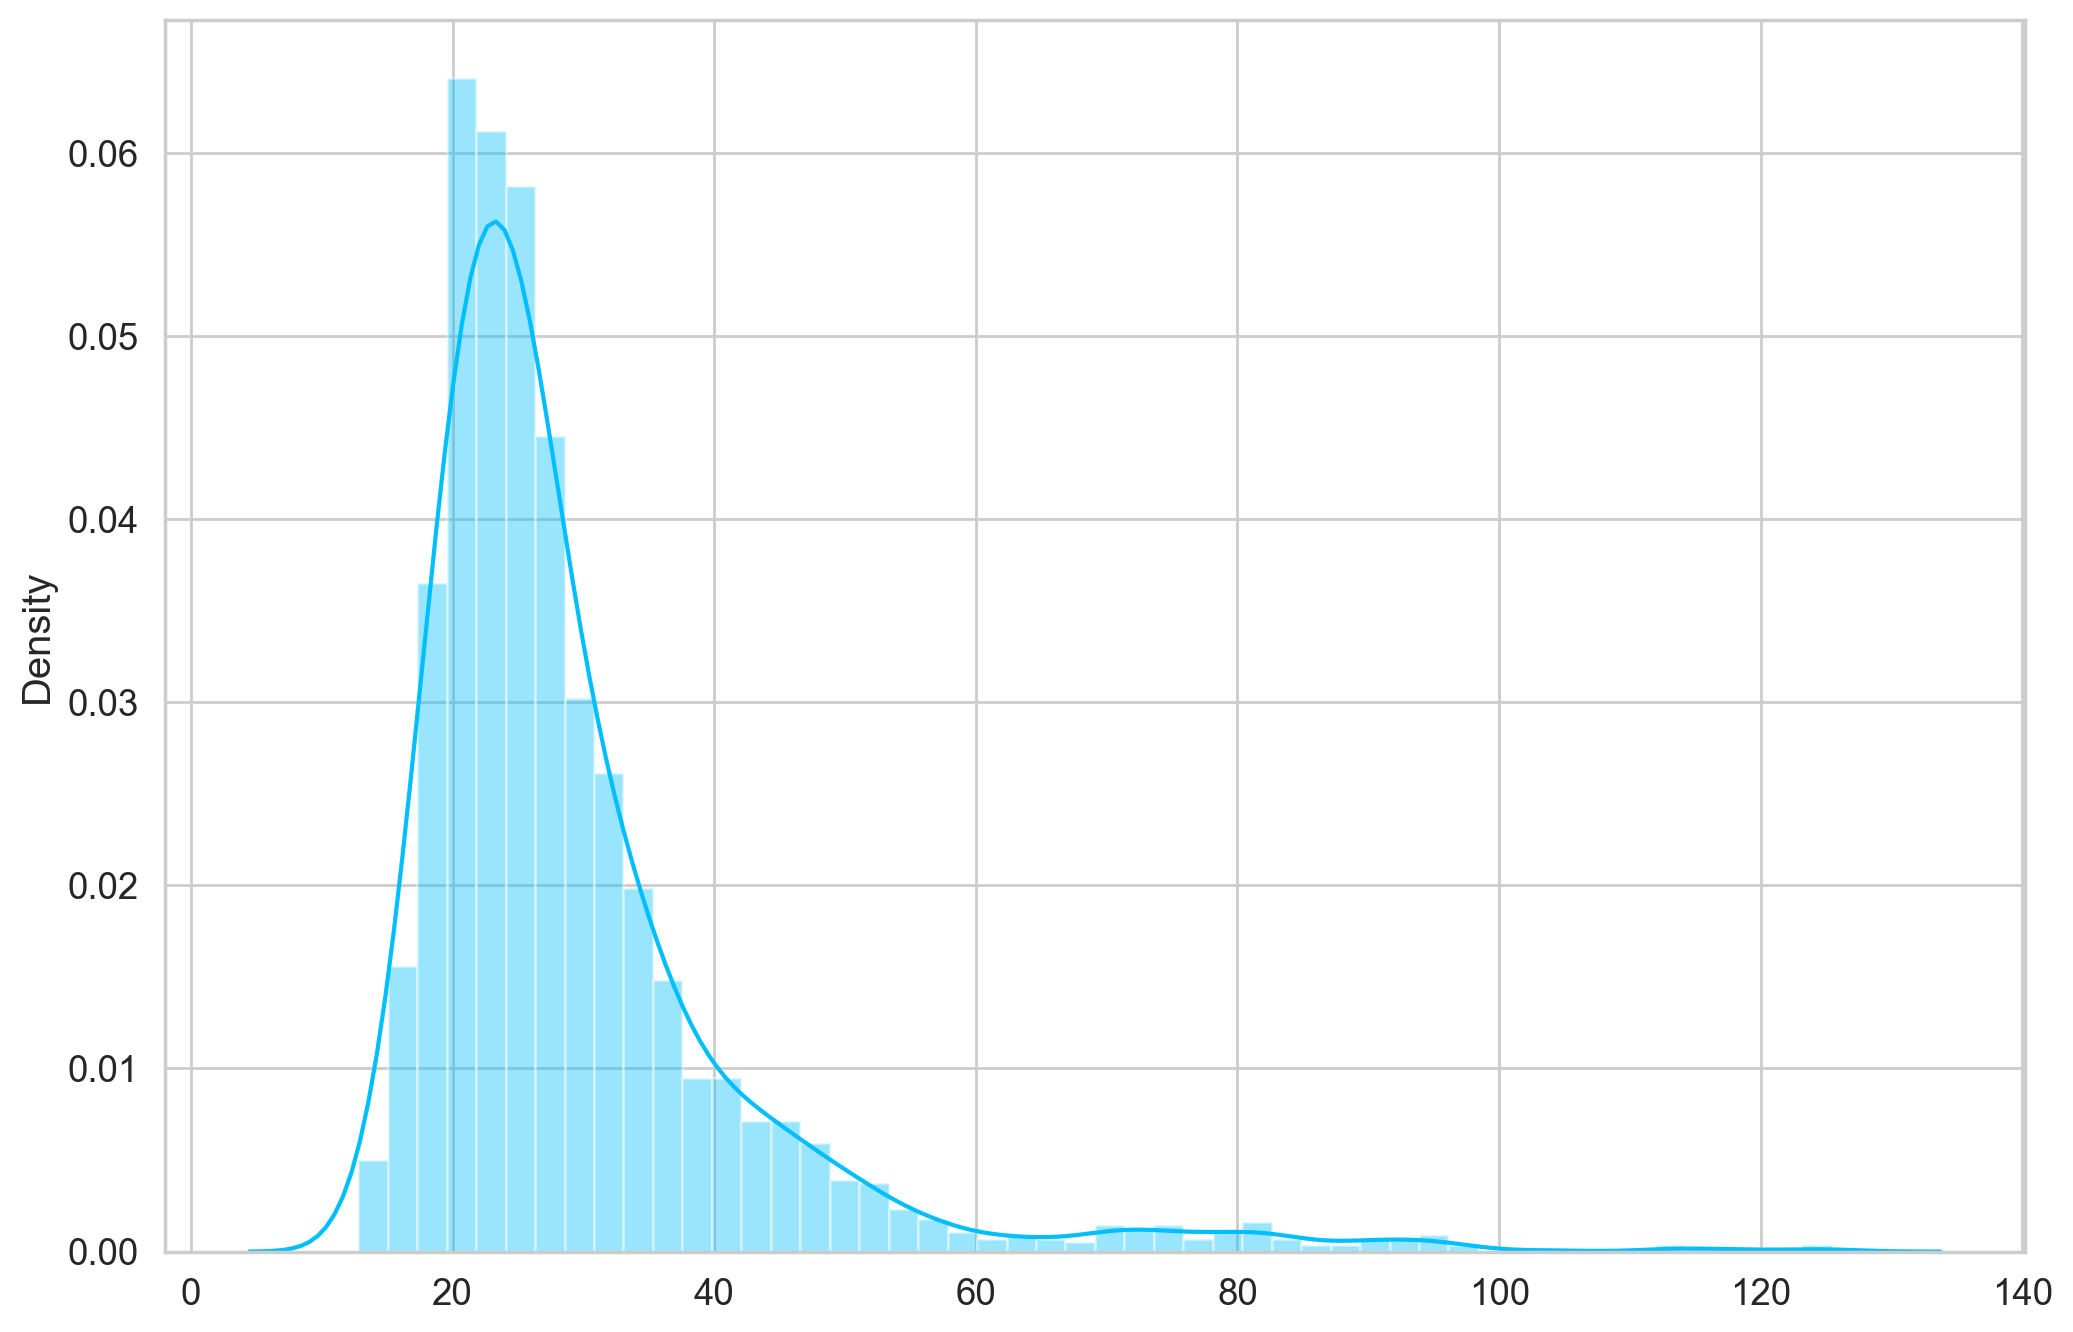

In [36]:
sns.distplot(losses, bins= 50, kde= True)

In [37]:
THRESHOLD = 26

/var/folders/tc/s_gvvcyn16nc25cl5cvpsftr0000gn/T/ipykernel_69748/3784438109.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(pred_losses, bins= 50, kde= True);


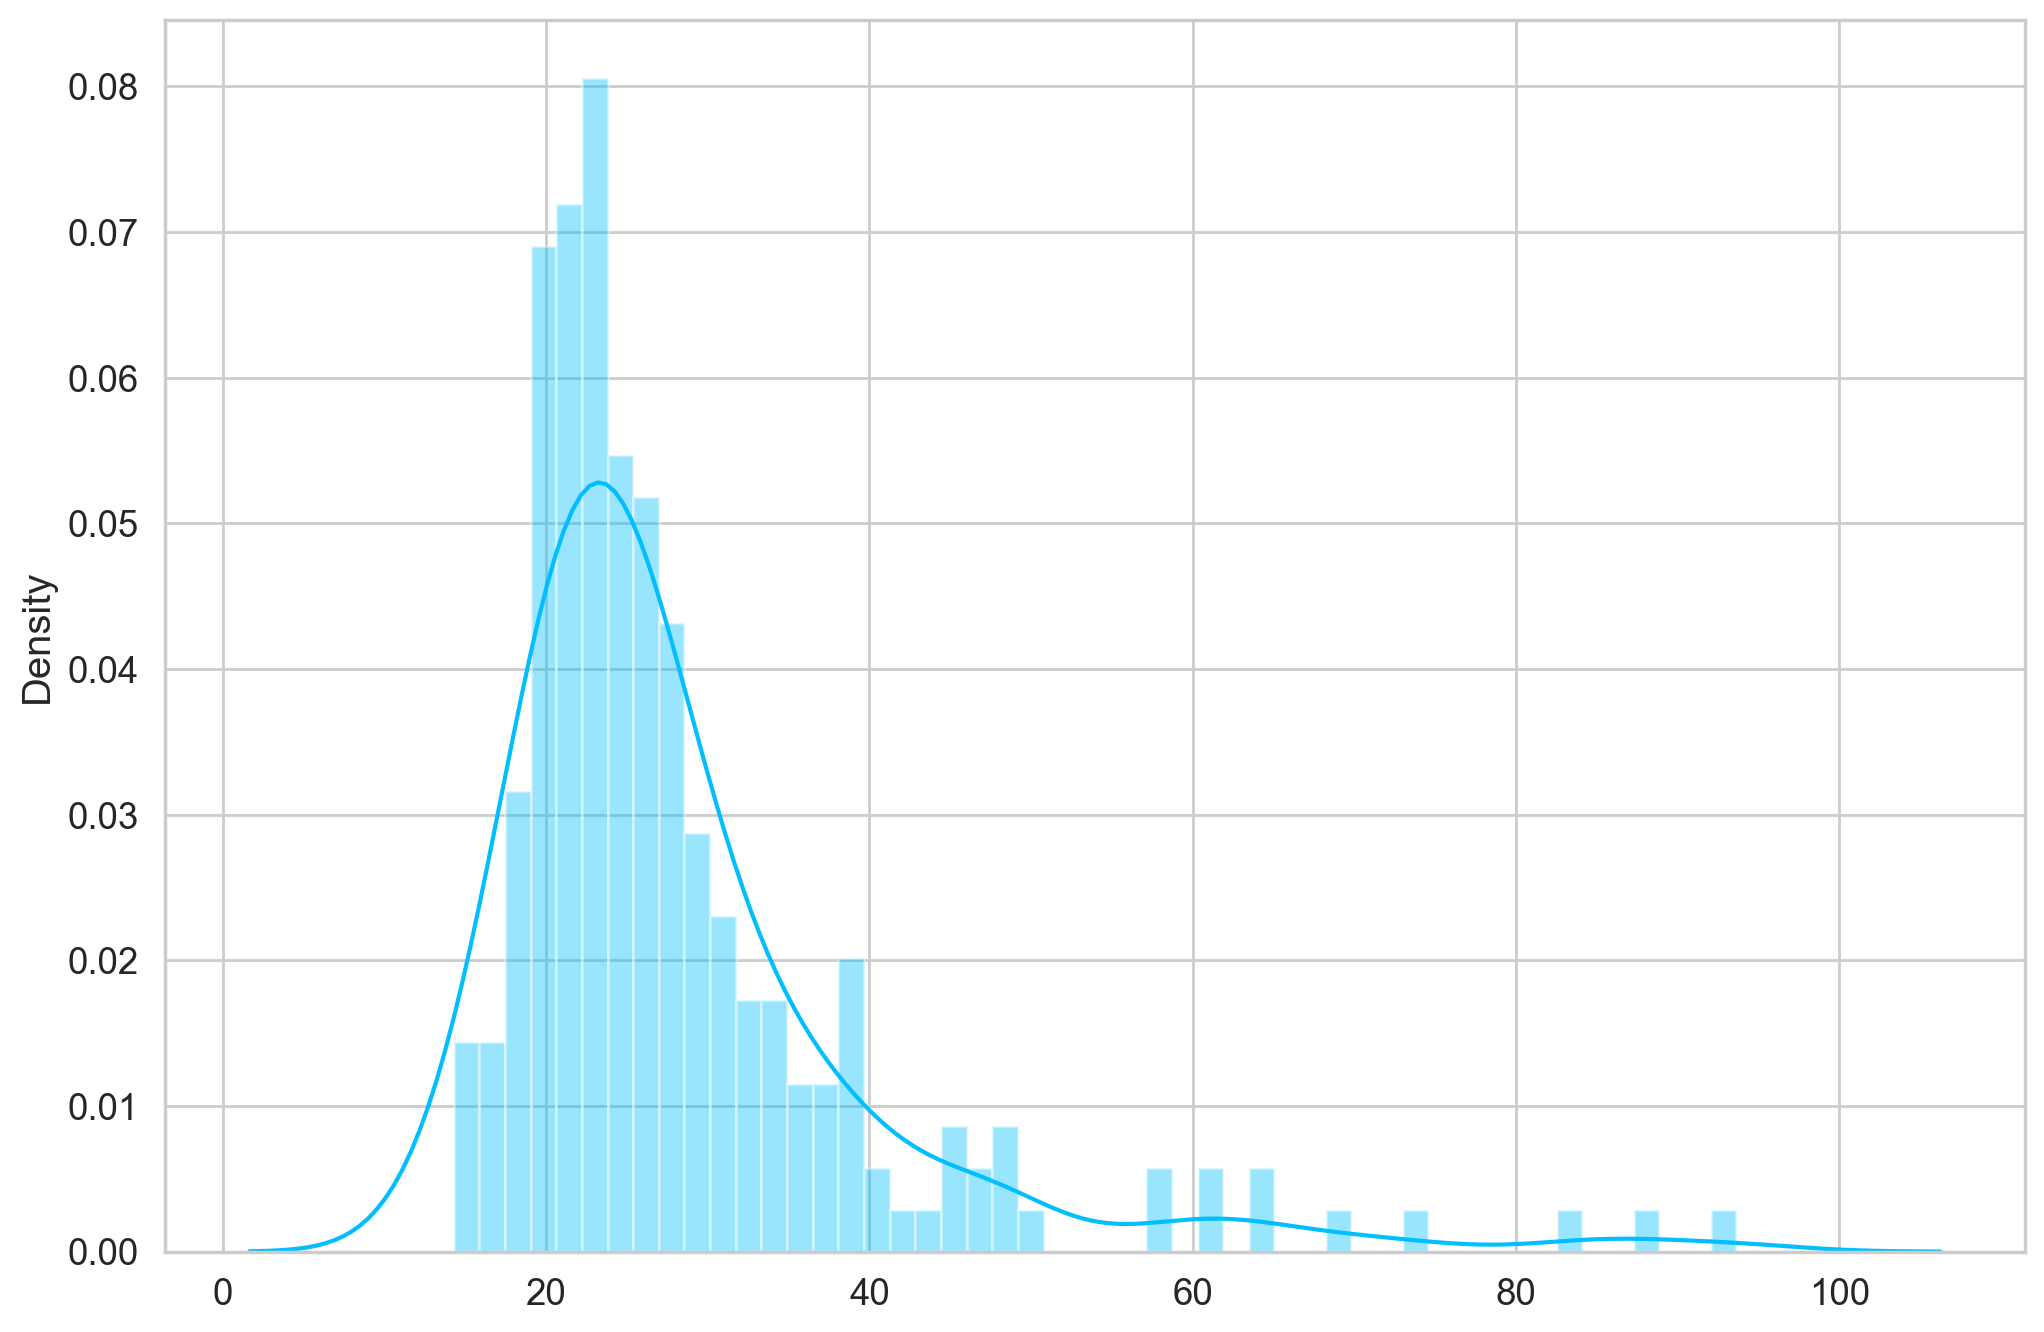

In [38]:
predictions, pred_losses = predict(model, test_normal_dataset)

sns.distplot(pred_losses, bins= 50, kde= True);

In [40]:
correct = sum(l <= THRESHOLD for l in pred_losses)
print(f'Correct normal precitions: {correct}/{len(test_normal_dataset)}')

Correct normal precitions: 123/219


/var/folders/tc/s_gvvcyn16nc25cl5cvpsftr0000gn/T/ipykernel_69748/811703296.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(pred_losses, bins= 50, kde= True);


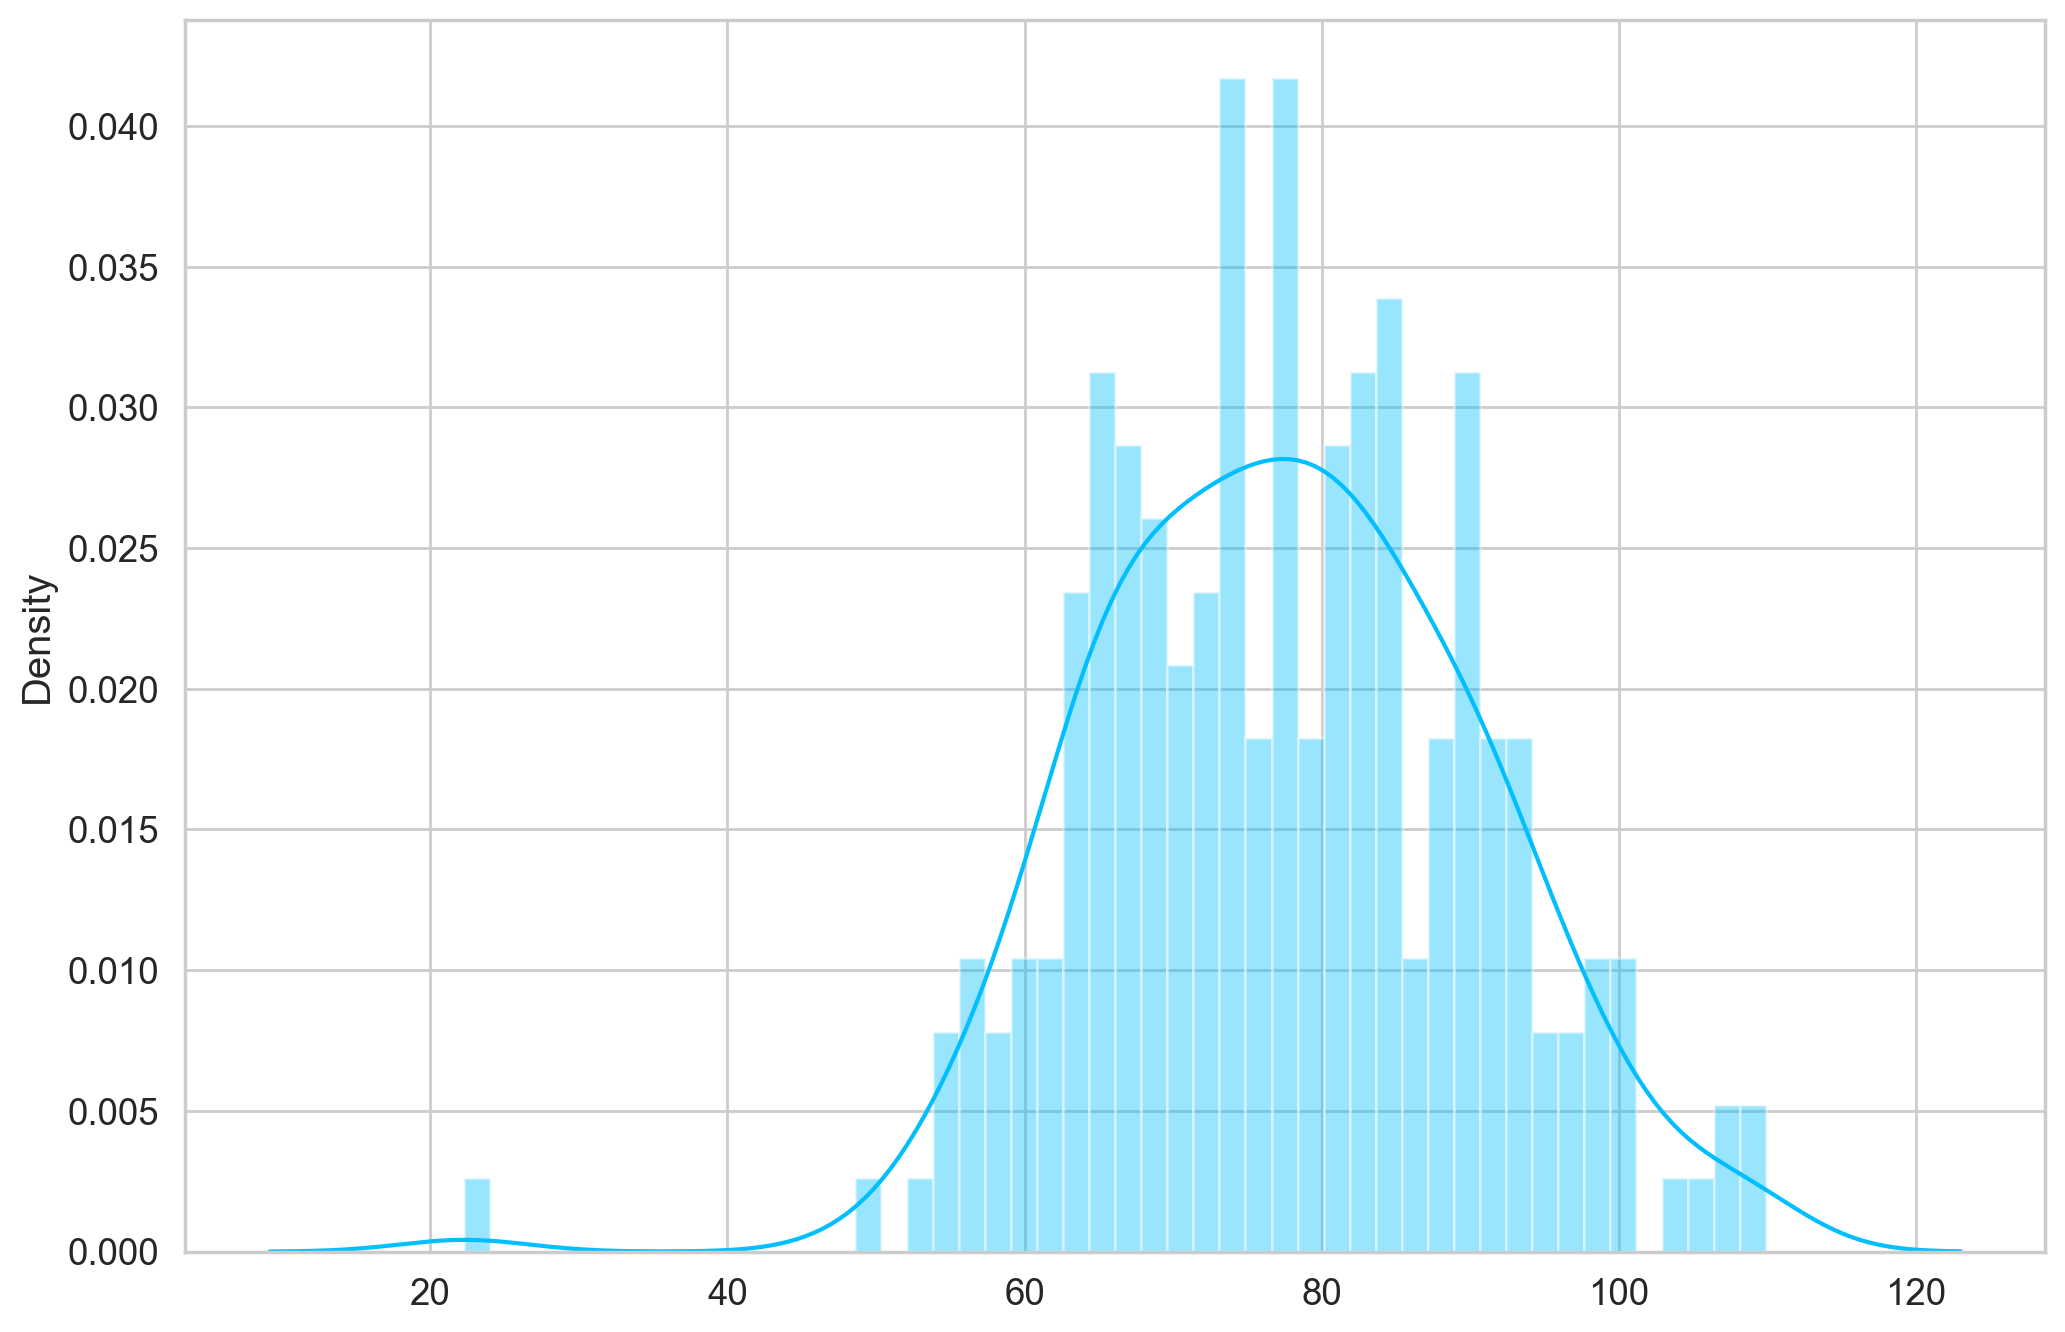

In [41]:
anomaly_dataset = test_anomaly_dataset[:len(test_normal_dataset)]

predictions, pred_losses = predict(model, anomaly_dataset)

sns.distplot(pred_losses, bins= 50, kde= True);

In [42]:
correct = sum(l > THRESHOLD for l in pred_losses)
print(f'Correct anomaly precitions: {correct}/{len(anomaly_dataset)}')

Correct anomaly precitions: 218/219


In [44]:
def plot_prediction(data, model, title, ax):
    predictions, pred_losses = predict(model, [data])
    
    ax.plot(data, label= 'true')
    ax.plot(predictions[0], label= 'predicted')
    ax.set_title(f'{title} (loss: {np.around(pred_losses[0], 2)})') 
    ax.legend()

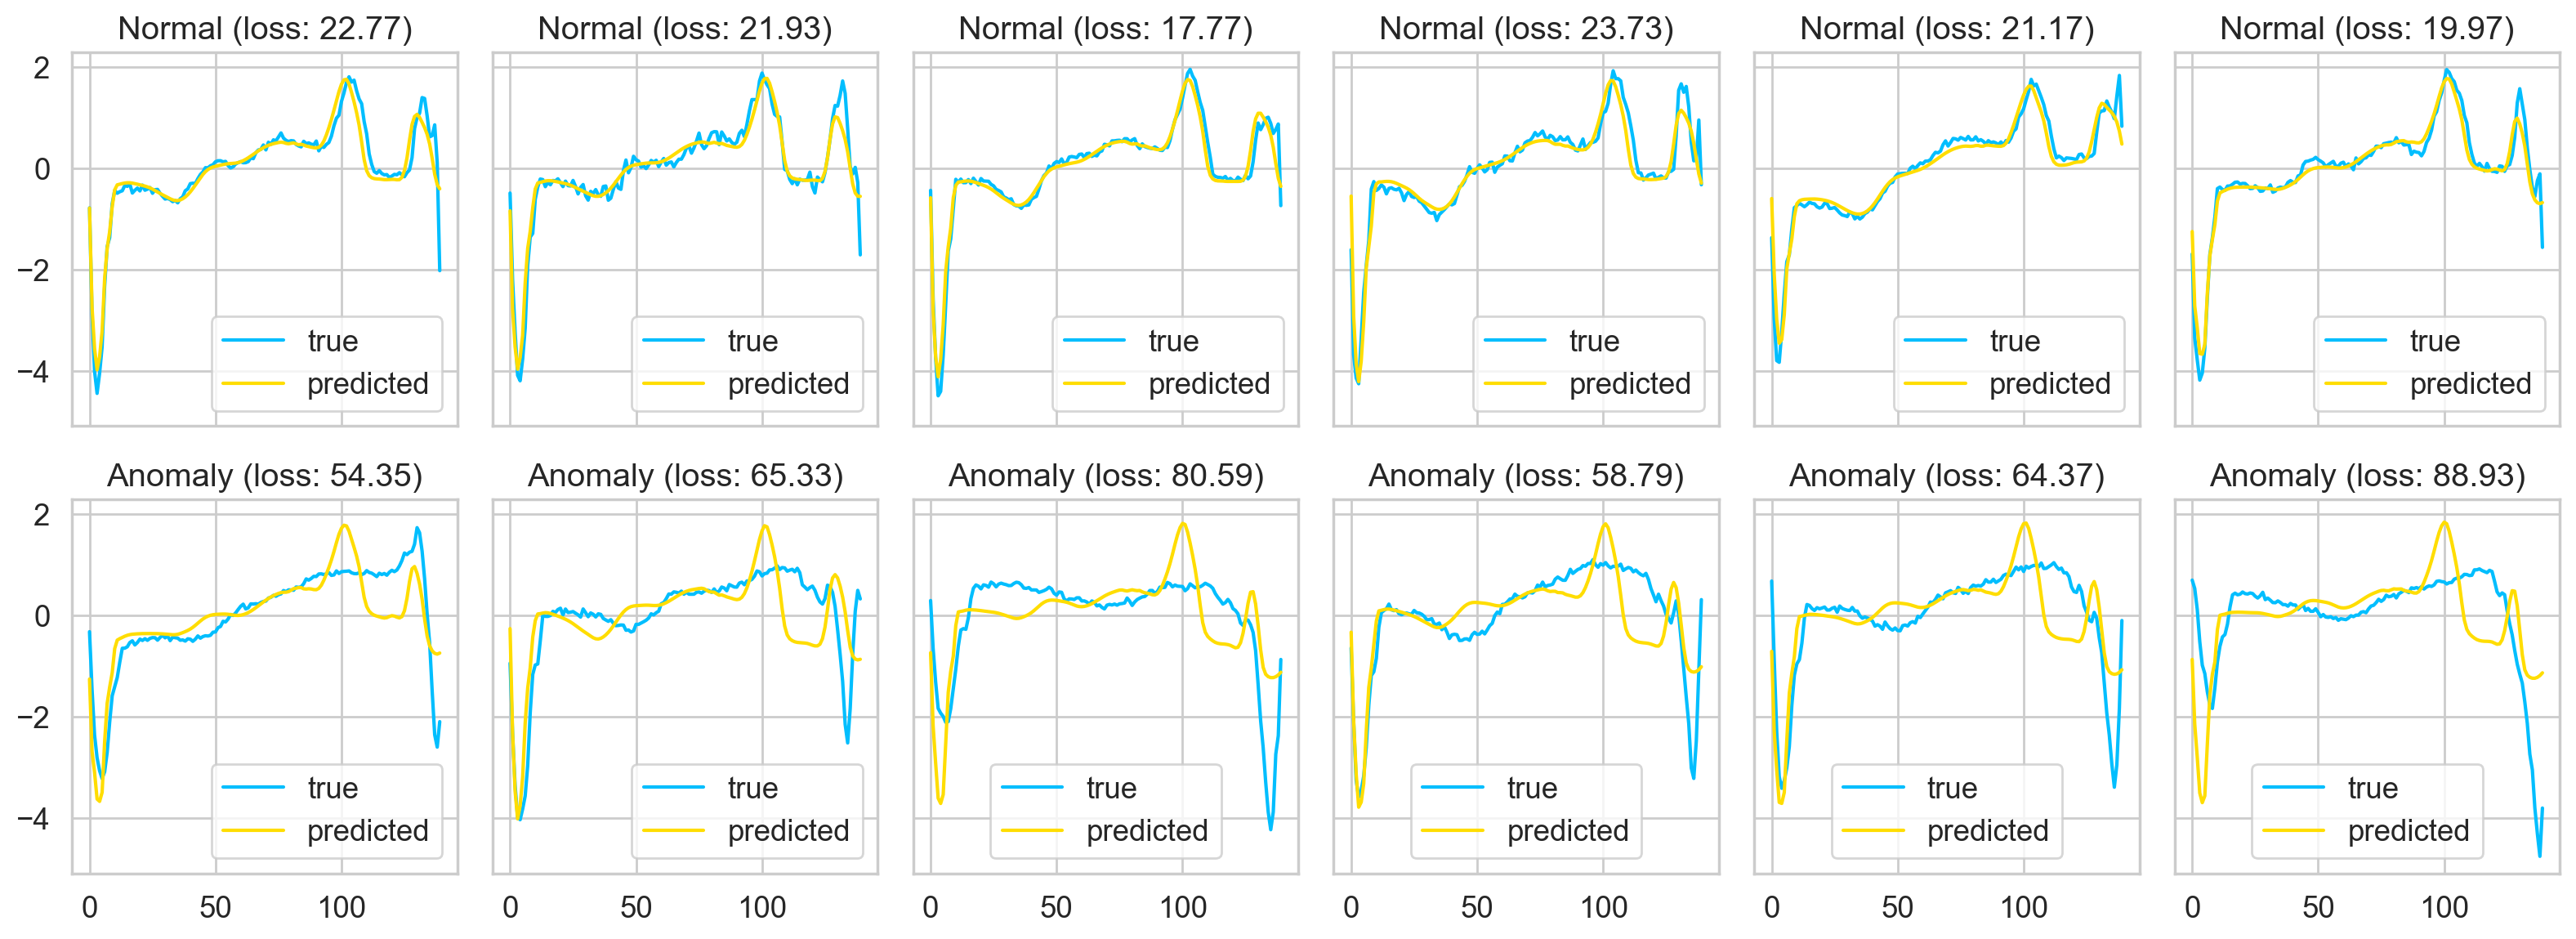

In [45]:

fig, axs = plt.subplots(
    nrows= 2,
    ncols= 6,
    sharex = True,
    sharey = True,
    figsize = (16, 6)
)


for i, data in enumerate(test_normal_dataset[:6]):
    plot_prediction(data, model, title= 'Normal', ax = axs[0, i])
    
for i, data in enumerate(test_anomaly_dataset[:6]):
    plot_prediction(data, model, title= 'Anomaly', ax = axs[1, i])

fig.tight_layout();